In [3]:
# Run this cell first to install required packages
# !pip install gymnasium

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
class TileCoding:
    def __init__(self, n_tilings=8, n_tiles=8):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        # State bounds for CartPole [pos, vel, angle, angular_vel]
        self.state_bounds = np.array([[-2.4, 2.4], [-3.0, 3.0], [-0.5, 0.5], [-2.0, 2.0]])
        self.tile_sizes = (self.state_bounds[:, 1] - self.state_bounds[:, 0]) / (n_tiles - 1)
        
    def get_tiles(self, state):
        """Get tile indices for given state"""
        tiles = []
        for tiling in range(self.n_tilings):
            # Offset each tiling
            offset = tiling * self.tile_sizes / self.n_tilings
            coords = ((state - self.state_bounds[:, 0]) / self.tile_sizes).astype(int) + offset.astype(int)
            # Ensure coordinates are within bounds
            coords = np.clip(coords, 0, self.n_tiles - 1)
            # Calculate tile index
            tile_index = tiling * (self.n_tiles ** 4) + \
                         coords[0] * (self.n_tiles ** 3) + \
                         coords[1] * (self.n_tiles ** 2) + \
                         coords[2] * self.n_tiles + \
                         coords[3]
            tiles.append(int(tile_index))
        return tiles

In [4]:
class QLambdaWatkinsAgent:
    def __init__(self, n_actions=2, n_tilings=8, lambda_=0.9, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.n_actions = n_actions
        self.lambda_ = lambda_
        self.alpha = alpha / n_tilings  # Normalize learning rate
        self.gamma = gamma
        self.epsilon = epsilon
        
        self.tile_coder = TileCoding(n_tilings, n_tiles=8)
        # Total number of tiles
        self.n_tiles_total = n_tilings * (8 ** 4)
        # Weight vector for each action
        self.weights = np.zeros((n_actions, self.n_tiles_total))
        # Eligibility traces
        self.traces = np.zeros((n_actions, self.n_tiles_total))
        
    def get_q_value(self, tiles, action):
        """Get Q-value for state-action pair"""
        return np.sum(self.weights[action][tiles])
    
    def choose_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        tiles = self.tile_coder.get_tiles(state)
        
        if training and np.random.rand() < self.epsilon:
            return np.random.choice(self.n_actions)
        
        q_values = [self.get_q_value(tiles, a) for a in range(self.n_actions)]
        return np.argmax(q_values)
    
    def update(self, state, action, reward, next_state, done):
        """Q(λ) Watkins update"""
        # Get tiles for current and next states
        tiles = self.tile_coder.get_tiles(state)
        next_tiles = self.tile_coder.get_tiles(next_state)
        
        # Compute current Q-value
        q_current = self.get_q_value(tiles, action)
        
        # Compute next Q-values and max Q-value
        if done:
            q_next_max = 0
        else:
            next_q_values = [self.get_q_value(next_tiles, a) for a in range(self.n_actions)]
            q_next_max = np.max(next_q_values)
        
        # Compute TD error
        td_error = reward + self.gamma * q_next_max - q_current
        
        # Watkins Q(λ): Only continue traces if next action is greedy
        if not done:
            next_action = self.choose_action(next_state, training=False)  # Greedy action
            next_q_values = [self.get_q_value(next_tiles, a) for a in range(self.n_actions)]
            greedy_action = np.argmax(next_q_values)
            
            # If next action is greedy, continue traces; otherwise, reset
            if next_action != greedy_action:
                self.traces = np.zeros_like(self.traces)
        
        # Update eligibility traces
        self.traces *= self.gamma * self.lambda_
        self.traces[action][tiles] += 1
        
        # Update weights
        self.weights += self.alpha * td_error * self.traces
    
    def reset_traces(self):
        """Reset eligibility traces"""
        self.traces = np.zeros_like(self.traces)

In [5]:
def run_episode(env, agent, training=True):
    """Run a single episode"""
    state, _ = env.reset()
    
    agent.reset_traces()
    action = agent.choose_action(state, training)
    
    total_reward = 0
    steps = 0
    
    while True:
        # Take action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        total_reward += reward
        steps += 1
        
        # Update agent (only during training)
        if training:
            agent.update(state, action, reward, next_state, done)
        
        # Choose next action for next iteration (ε-greedy)
        if not done:
            action = agent.choose_action(next_state, training)
        
        # Update state
        state = next_state
        
        if done:
            break
    
    return total_reward, steps

def train_agent(env, agent, n_episodes=1000):
    """Train the agent"""
    rewards = []
    steps_list = []
    
    for episode in range(n_episodes):
        reward, steps = run_episode(env, agent, training=True)
        rewards.append(reward)
        steps_list.append(steps)
        
        # Decay epsilon
        if agent.epsilon > 0.01:
            agent.epsilon *= 0.995
        
        # Print progress
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards[-100:])
            print(f"Episode {episode+1}/{n_episodes}, Average Reward: {avg_reward:.2f}")
    
    return rewards, steps_list

def test_agent(env, agent, n_episodes=100):
    """Test the trained agent"""
    rewards = []
    for _ in range(n_episodes):
        reward, _ = run_episode(env, agent, training=False)
        rewards.append(reward)
    return np.mean(rewards), np.std(rewards)

In [6]:
# Create environment
env = gym.make('CartPole-v1')

# Create agent
agent = QLambdaWatkinsAgent(
    n_actions=env.action_space.n,
    n_tilings=8,
    lambda_=0.9,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0
)

# Train agent
print("Training Q(λ) Watkins agent...")
train_rewards, train_steps = train_agent(env, agent, n_episodes=1000)

# Test agent
print("\nTesting trained agent...")
mean_reward, std_reward = test_agent(env, agent, n_episodes=100)
print(f"Test Results: Mean={mean_reward:.2f}, Std={std_reward:.2f}")

# Close environment
env.close()

Training Q(λ) Watkins agent...
Episode 100/1000, Average Reward: 31.33
Episode 200/1000, Average Reward: 46.63
Episode 300/1000, Average Reward: 62.82
Episode 400/1000, Average Reward: 68.66
Episode 500/1000, Average Reward: 92.43
Episode 600/1000, Average Reward: 152.52
Episode 700/1000, Average Reward: 155.29
Episode 800/1000, Average Reward: 213.88
Episode 900/1000, Average Reward: 208.22
Episode 1000/1000, Average Reward: 177.12

Testing trained agent...
Test Results: Mean=353.44, Std=125.64


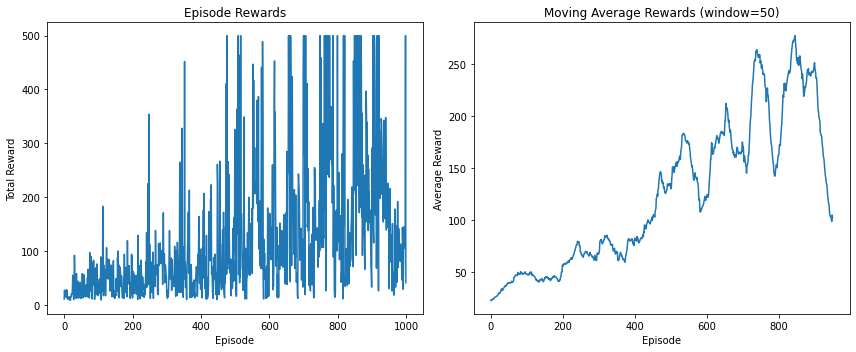

In [7]:
# Plot training progress
plt.figure(figsize=(12, 5))

# Plot rewards
plt.subplot(1, 2, 1)
plt.plot(train_rewards)
plt.title('Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Total Reward')

# Plot moving average
window = 50
if len(train_rewards) >= window:
    moving_avg = np.convolve(train_rewards, np.ones(window)/window, mode='valid')
    plt.subplot(1, 2, 2)
    plt.plot(moving_avg)
    plt.title(f'Moving Average Rewards (window={window})')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward')

plt.tight_layout()
plt.show()

In [8]:
def visualize_agent_text(agent, num_episodes=3):
    """Visualize the trained agent with text output"""
    # Create environment
    env = gym.make('CartPole-v1')
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        agent.reset_traces()
        action = agent.choose_action(state, training=False)
        
        total_reward = 0
        steps = 0
        
        print(f"Episode {episode + 1}:")
        print("Step | Position | Velocity | Angle | Angular Vel | Action")
        print("-" * 60)
        
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            total_reward += reward
            steps += 1
            
            # Choose next action
            if not done:
                next_action = agent.choose_action(next_state, training=False)
            
            # Print state information every 20 steps
            if steps % 20 == 1 or done:
                print(f"{steps:4d} | {state[0]:8.3f} | {state[1]:8.3f} | {state[2]:6.3f} | {state[3]:11.3f} | {action}")
            
            # Update state and action
            state = next_state
            if not done:
                action = next_action
            
            if done:
                print(f"  Episode finished after {steps} steps with total reward {total_reward}")
                print()
                break
    
    env.close()

# Run text-based visualization
print("Visualizing trained agent performance (text-based)...")
visualize_agent_text(agent, num_episodes=3)

Visualizing trained agent performance (text-based)...
Episode 1:
Step | Position | Velocity | Angle | Angular Vel | Action
------------------------------------------------------------
   1 |    0.017 |   -0.003 |  0.012 |      -0.031 | 0
  21 |    0.052 |    0.764 | -0.010 |      -0.917 | 0
  41 |    0.065 |   -0.387 | -0.019 |       0.405 | 1
  61 |   -0.036 |    0.384 |  0.076 |      -0.563 | 1
  81 |    0.041 |   -0.381 | -0.057 |       0.273 | 0
 101 |   -0.141 |    0.006 |  0.083 |      -0.236 | 1
 121 |   -0.088 |    0.769 | -0.016 |      -1.030 | 0
 141 |   -0.104 |   -0.384 | -0.018 |       0.348 | 1
 161 |   -0.219 |   -0.390 |  0.071 |       0.486 | 1
 181 |   -0.112 |   -0.385 | -0.098 |       0.361 | 0
 201 |   -0.302 |   -0.378 |  0.046 |       0.203 | 0
 221 |   -0.370 |    0.383 |  0.078 |      -0.527 | 0
 241 |   -0.229 |    0.756 | -0.037 |      -0.736 | 1
 261 |   -0.212 |   -0.011 |  0.021 |       0.135 | 0
 281 |   -0.070 |    0.761 | -0.095 |      -0.855 | 0
 301 |